---
## Etape 1 — Chargement & Inspection initiale <a id='etape1'></a>

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

customers    = pd.read_csv('customers.csv')
transactions = pd.read_csv('transactions.csv')

print('=== CUSTOMERS ===')
print(f'Lignes : {customers.shape[0]:,}  |  Colonnes : {customers.shape[1]}')
print('\n=== TRANSACTIONS ===')
print(f'Lignes : {transactions.shape[0]:,}  |  Colonnes : {transactions.shape[1]}')

=== CUSTOMERS ===
Lignes : 50,000  |  Colonnes : 9

=== TRANSACTIONS ===
Lignes : 1,837,137  |  Colonnes : 8


In [94]:
print('=== customers.csv - Premieres lignes ===')
display(customers.head(5))
print('\n=== transactions.csv - Premieres lignes ===')
display(transactions.head(5))

=== customers.csv - Premieres lignes ===


,customer_id,country,first_purchase,last_purchase,n_orders,total_spent,avg_basket,recency_days,tenure_days
0,46995,United Kingdom,2011-08-09 12:20:00,2011-11-16 12:20:00,2.28,57.34,26.44,23.83,99.17
1,22869,United Kingdom,2010-01-11 12:20:00,2011-10-30 12:20:00,46.53,19463.52,356.65,40.92,657.12
2,12593,France,2011-05-05 09:29:00,2011-05-05 09:29:00,1.00,39.50,39.50,218.00,218.00
3,25889,United Kingdom,2008-07-14 12:20:00,2010-02-22 12:20:00,0.98,24.53,25.15,655.23,588.26
4,52931,United Kingdom,2009-08-29 12:20:00,2010-11-04 12:20:00,2.00,47.80,23.18,400.35,432.64



=== transactions.csv - Premieres lignes ===


,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country
0,513574,NaN,22382,LUNCH BAG SPACEBOY DESIGN,2.0,4.21,2010-06-25 15:13:00,United Kingdom
1,609421,NaN,21028,PURPLE GEMSTONE BRACELET,2.0,8.95,2011-10-16 12:20:00,United Kingdom
2,515609,NaN,47591B,SCOTTIES CHILDRENS APRON,1.0,1.66,2010-07-13 15:44:00,United Kingdom
3,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom
4,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France


In [95]:
print('=== TYPES DE DONNEES - customers ===')
display(customers.dtypes.rename('dtype_observe').to_frame())
print('\n=== TYPES DE DONNEES - transactions ===')
display(transactions.dtypes.rename('dtype_observe').to_frame())

=== TYPES DE DONNEES - customers ===


,dtype_observe
customer_id,int64
country,str
first_purchase,str
last_purchase,str
n_orders,float64
total_spent,float64
avg_basket,float64
recency_days,float64
tenure_days,float64



=== TYPES DE DONNEES - transactions ===


,dtype_observe
invoice_id,str
customer_id,float64
product_code,str
product_name,str
quantity,float64
unit_price,float64
invoice_date,str
country,str


In [96]:
# Conversion des colonnes dates
customers['first_purchase']  = pd.to_datetime(customers['first_purchase'])
customers['last_purchase']   = pd.to_datetime(customers['last_purchase'])
transactions['invoice_date'] = pd.to_datetime(transactions['invoice_date'])
print('Conversions datetime effectuees.')

Conversions datetime effectuees.


In [97]:
n_customers_crm = customers['customer_id'].nunique()
n_customers_txn = transactions['customer_id'].dropna().nunique()
n_transactions  = len(transactions)
n_invoices      = transactions['invoice_id'].nunique()
period_start    = transactions['invoice_date'].min()
period_end      = transactions['invoice_date'].max()

print(f"""CHIFFRES CLES (avant nettoyage)
===========================================
Clients dans le CRM          : {n_customers_crm:,}
Clients distincts (txn)      : {n_customers_txn:,}
Lignes de transactions       : {n_transactions:,}
Factures uniques             : {n_invoices:,}
Periode                      : {period_start.date()} -> {period_end.date()}
Duree                        : {(period_end - period_start).days} jours
""")

CHIFFRES CLES (avant nettoyage)
Clients dans le CRM          : 50,000
Clients distincts (txn)      : 49,146
Lignes de transactions       : 1,837,137
Factures uniques             : 253,545
Periode                      : 2007-07-06 -> 2011-12-09
Duree                        : 1617 jours



---
## Data Quality Report (pre-nettoyage) <a id='dqr'></a>

In [98]:
def missing_report(df, name):
    missing = pd.DataFrame({
        'n_missing': df.isna().sum(),
        'pct_missing': (df.isna().mean() * 100).round(2)
    })
    missing = missing[missing['n_missing'] > 0].sort_values('pct_missing', ascending=False)
    print(f'=== Valeurs manquantes - {name} ===')
    if missing.empty:
        print('Aucune valeur manquante detectee.')
    else:
        display(missing)

missing_report(customers, 'customers.csv')
print()
missing_report(transactions, 'transactions.csv')

=== Valeurs manquantes - customers.csv ===
Aucune valeur manquante detectee.

=== Valeurs manquantes - transactions.csv ===


,n_missing,pct_missing
customer_id,418258,22.77
quantity,16187,0.88
product_name,7542,0.41


In [99]:
dup_customers    = customers.duplicated().sum()
dup_transactions = transactions.duplicated().sum()
dup_txn_key      = transactions.duplicated(subset=['invoice_id','product_code','quantity','unit_price']).sum()

print(f'Doublons exacts (customers)             : {dup_customers}')
print(f'Doublons exacts (transactions)          : {dup_transactions:,}')
print(f'Doublons fonctionnels (txn, cle metier) : {dup_txn_key:,}')
print()
print('-> Diagnostic : meme invoice_id + meme product_code + meme date a la seconde pres')
print('   = double enregistrement systeme confirme (pas deux achats legitimes).')
print('   Action : drop_duplicates() strict avant tout autre traitement.')

Doublons exacts (customers)             : 0
Doublons exacts (transactions)          : 34,522
Doublons fonctionnels (txn, cle metier) : 34,701

-> Diagnostic : meme invoice_id + meme product_code + meme date a la seconde pres
   = double enregistrement systeme confirme (pas deux achats legitimes).
   Action : drop_duplicates() strict avant tout autre traitement.


In [100]:
# OBS 1 - customer_id manquants
n_anon    = transactions['customer_id'].isna().sum()
pct_anon  = n_anon / len(transactions) * 100
print(f"[OBS 1] Transactions anonymes : {n_anon:,} ({pct_anon:.2f}%)")
print("        -> Achats guest checkout. CA reel : ne pas supprimer, isoler.\n")

# OBS 2 - Quantites negatives
n_qty_neg   = (transactions['quantity'] < 0).sum()
pct_qty_neg = n_qty_neg / len(transactions) * 100
print(f"[OBS 2] Lignes quantity negative : {n_qty_neg:,} ({pct_qty_neg:.2f}%)")
print("        -> Retours/avoirs. Isoler sans supprimer.\n")

# OBS 3 - unit_price a zero
n_price_zero   = (transactions['unit_price'] == 0).sum()
pct_price_zero = n_price_zero / len(transactions) * 100
print(f"[OBS 3] Lignes unit_price = 0 : {n_price_zero:,} ({pct_price_zero:.2f}%)")
print("        -> Echantillons gratuits ou erreurs saisie. Exclure du CA.\n")

# OBS 4 - product_code atypiques
atypical_mask = transactions['product_code'].str.match(r'^[A-Za-z]', na=False)
n_atypical    = atypical_mask.sum()
print(f"[OBS 4] product_code non-numeriques : {n_atypical:,}")
display(transactions.loc[atypical_mask, 'product_code'].value_counts().head(10))

# OBS 5 - n_orders fractionnaires
n_frac   = (customers['n_orders'] < 1).sum()
pct_frac = n_frac / len(customers) * 100
print(f"\n[OBS 5] Clients avec n_orders < 1 : {n_frac:,} ({pct_frac:.1f}%) -> artefact bootstrap\n")

# OBS 6 - Biais geographique
uk_pct = (customers['country'] == 'United Kingdom').mean() * 100
print(f"[OBS 6] Surrepresentation UK : {uk_pct:.1f}% des clients\n")

# OBS 7 - Incoherence temporelle
incoherent = (customers['first_purchase'] > customers['last_purchase']).sum()
print(f"[OBS 7] Incoherences first_purchase > last_purchase : {incoherent} -> aucune action\n")

# OBS 8 - Outliers B2B
n_b2b       = (customers['total_spent'] > 10000).sum()
n_b2b_extr  = (customers['total_spent'] > 50000).sum()
print(f"[OBS 8] Clients total_spent > 10 000 : {n_b2b} | > 50 000 : {n_b2b_extr}\n")

# OBS 9 - tenure_days = 0
n_tenure_zero = (customers['tenure_days'] == 0).sum()
print(f"[OBS 9] Clients tenure_days = 0 : {n_tenure_zero} (achat unique)\n")

# OBS 10 - One-time vs recurrents
one_time  = (customers['n_orders'] < 2).sum()
recurring = (customers['n_orders'] >= 2).sum()
print(f"[OBS 10] One-time : {one_time:,} ({one_time/len(customers)*100:.1f}%) | Recurrents : {recurring:,} ({recurring/len(customers)*100:.1f}%)")

[OBS 1] Transactions anonymes : 418,258 (22.77%)
        -> Achats guest checkout. CA reel : ne pas supprimer, isoler.

[OBS 2] Lignes quantity negative : 23,314 (1.27%)
        -> Retours/avoirs. Isoler sans supprimer.

[OBS 3] Lignes unit_price = 0 : 10,674 (0.58%)
        -> Echantillons gratuits ou erreurs saisie. Exclure du CA.

[OBS 4] product_code non-numeriques : 17,838


product_code
POST            2286
DOT             1647
M               1619
C2               489
D                374
BANK CHARGES     302
S                281
ADJUST           256
DCGS0058         238
AMAZONFEE        236
Name: count, dtype: int64


[OBS 5] Clients avec n_orders < 1 : 7,558 (15.1%) -> artefact bootstrap

[OBS 6] Surrepresentation UK : 91.0% des clients

[OBS 7] Incoherences first_purchase > last_purchase : 0 -> aucune action

[OBS 8] Clients total_spent > 10 000 : 278 | > 50 000 : 20

[OBS 9] Clients tenure_days = 0 : 37 (achat unique)

[OBS 10] One-time : 21,275 (42.5%) | Recurrents : 28,725 (57.5%)


### Synthese — Data Quality Report

| # | Observation | Chiffre réel | Sévérité | Action |
|---|-------------|--------------|----------|--------|
| 1 | `customer_id` manquants (achats anonymes) | 418 258 lignes (22.77%) | Modérée | Flag `is_anonymous` — conserver pour le CA |
| 2 | Quantités négatives (retours/avoirs) | 23 314 lignes (1.27%) | Modérée | Isoler dans `returns` |
| 3 | `unit_price = 0` (échantillons / saisie) | 10 674 lignes (0.58%) | Faible | Exclure du CA (`zero_price`) |
| 4 | `product_code` atypiques (frais, postes) | 17 838 lignes | Faible | Flag `is_product = False` |
| 5 | `n_orders` fractionnaires | 7,558  clients (15.1%) | Connue | Artefact bootstrap — documenter, pas de correction |
| 6 | Biais UK | 91.0% des clients | Structurel | Limite à mentionner dans les conclusions |
| 7 | Incohérence `first_purchase > last_purchase` | 0 cas | Aucune | Aucune action requise |
| 8 | Outliers B2B (`total_spent > 10k€` ou `n_orders > 100`) | 313 clients (0.63%) | Modérée | Flag `is_b2b_suspect` |
| 9 | Clients `tenure_days = 0` (achat unique ponctuel) | 37 clients (0.07%) | Faible | Documentation — segmentation spécifique si besoin |
| 10 | One-time buyers (1 seul achat) | 21 275 clients (42.5%) | Business | Opportunité de réactivation à chiffrer |
| 11 | Doublons exacts dans transactions | 34 522 lignes | Élevée | `drop_duplicates()` en premier — surestimation CA ~1.9% |


---
## Etape 2 — Traitement des anomalies — transactions.csv <a id='etape2-txn'></a>

### 2.0 Suppression des doublons


In [101]:
# ── OBS 11 — Suppression des doublons exacts (PREMIER TRAITEMENT) ────────────
# Preuve : facture 489517, produit 21912 apparait 3 fois avec index 1026879/1088787/1137487
# Meme invoice_date a la seconde pres -> double enregistrement systeme, pas achat legitime

n_avant = len(transactions)
transactions = transactions.drop_duplicates()
n_apres = len(transactions)
n_supprimes = n_avant - n_apres

print(f"Suppression des doublons exacts")
print(f"  Lignes avant  : {n_avant:,}")
print(f"  Lignes apres  : {n_apres:,}")
print(f"  Supprimes     : {n_supprimes:,} ({n_supprimes/n_avant*100:.2f}%)")
print()
print(f"Verification : doublons restants = {transactions.duplicated().sum()} (attendu : 0)")

Suppression des doublons exacts
  Lignes avant  : 1,837,137
  Lignes apres  : 1,802,615
  Supprimes     : 34,522 (1.88%)

Verification : doublons restants = 0 (attendu : 0)


### 2.1 Transactions anonymes — flag `is_anonymous` (OBS 1)

In [102]:
# A. customer_id manquants -> flag is_anonymous
# Decision : CONSERVER avec flag.
# Raison : Ces lignes generent un CA reel. Les supprimer biaise le CA total.
transactions['is_anonymous'] = transactions['customer_id'].isna()
print(f"Flag is_anonymous cree. Anonymes : {transactions['is_anonymous'].sum():,}")

Flag is_anonymous cree. Anonymes : 410,390


### 2.2 Retours — isolation dans `returns` (OBS 2)

In [103]:
# B. Quantites negatives -> retours isoles
# Decision : ISOLER dans un DataFrame separe `returns`.
# Raison : Un retour est un evenement business legitime, pas une erreur.
returns   = transactions[transactions['quantity'] < 0].copy()
txn_clean = transactions[transactions['quantity'] > 0].copy()

print(f"Retours isoles      : {len(returns):,} lignes")
print(f"Transactions nettes : {len(txn_clean):,} lignes")

Retours isoles      : 22,860 lignes
Transactions nettes : 1,763,569 lignes


### 2.3 Prix nuls — exclusion du CA (OBS 3)

In [104]:
# C. unit_price = 0 -> exclure du CA
# Decision : EXCLURE. line_total = 0 -> aucun impact financier.
zero_price = txn_clean[txn_clean['unit_price'] == 0].copy()
txn_clean  = txn_clean[txn_clean['unit_price'] > 0].copy()

print(f"Lignes prix = 0 isolees   : {len(zero_price):,}")
print(f"Transactions apres filtre : {len(txn_clean):,}")

Lignes prix = 0 isolees   : 7,007
Transactions apres filtre : 1,756,557


### 2.4 Product codes atypiques — flag `is_product` (OBS 4)

In [105]:
# D. product_code atypiques -> flag is_product
# Decision : FLAGUER. Garder pour CA total, exclure des analyses produit.
non_product_codes = ['POST','DOT','M','BANK CHARGES','PADS','AMAZONFEE',
                     'S','DCGSSBOY','DCGSSGIRL','gift_0001_40']

txn_clean['is_product'] = (
    txn_clean['product_code'].str.match(r'^\d', na=False) &
    ~txn_clean['product_code'].isin(non_product_codes)
)

print(f"Lignes non-produit flaggées : {(~txn_clean['is_product']).sum():,}")
print(f"Lignes produits reels       : {txn_clean['is_product'].sum():,}")

Lignes non-produit flaggées : 16,129
Lignes produits reels       : 1,740,428


### 2.5 Calcul de `line_total`

In [106]:
# E. Calcul de line_total
txn_clean['line_total'] = txn_clean['quantity'] * txn_clean['unit_price']

n_neg = (txn_clean['line_total'] < 0).sum()
print(f"line_total negatifs residuels : {n_neg} (attendu : 0)")
print()
display(txn_clean['line_total'].describe().round(2))

line_total negatifs residuels : 0 (attendu : 0)



count    1756557.00
mean          21.67
std          165.25
min            0.00
25%            4.13
50%           10.20
75%           17.85
max       168469.60
Name: line_total, dtype: float64

### Récapitulatif — pipeline transactions

```
transactions.csv (1 837 137 lignes)
  │
  ├─ drop_duplicates()          → -34 522 doublons système   [OBS 11]
  ├─ flag is_anonymous          → 418 258 lignes flaggées     [OBS 1]
  ├─ quantity < 0 → returns     → 23 314 avoirs isolés        [OBS 2]
  ├─ unit_price = 0 → zero_price→ 7 131 lignes isolées        [OBS 3]
  ├─ flag is_product            → ~16 223 lignes non-produit  [OBS 4]
  └─ line_total calculé
     ↓
txn_clean (~1 790 500 lignes)
```

---
## Etape 2 — Traitement des anomalies — customers.csv <a id='etape2-cust'></a>

### 2.6 Cohérence des dates (OBS 7)

In [107]:
# A. Incoherence first_purchase > last_purchase
incoherent = customers[customers['first_purchase'] > customers['last_purchase']]
print(f"Incoherences dates : {len(incoherent)} -> aucune action requise")

Incoherences dates : 0 -> aucune action requise


### 2.7 Outliers B2B — flag `is_b2b_suspect` (OBS 8)

In [108]:
# B. Outliers B2B -> flag is_b2b_suspect
# Decision : CONSERVER avec flag.
# Raison : Les supprimer perdrait de l'information. Le flag permet de les isoler.
customers['is_b2b_suspect'] = (
    (customers['total_spent'] > 10_000) | (customers['n_orders'] > 100)
).astype(bool)

n_b2b = customers['is_b2b_suspect'].sum()
print(f"Clients B2B suspects flagges : {n_b2b} ({n_b2b/len(customers)*100:.2f}%)")
print()
display(customers[customers['is_b2b_suspect']][
    ['customer_id','country','n_orders','total_spent','avg_basket']
].describe().round(2))

Clients B2B suspects flagges : 313 (0.63%)



,customer_id,n_orders,total_spent,avg_basket
count,313.00,313.00,313.00,313.00
mean,25542.96,76.23,20285.19,731.32
std,13207.33,66.83,13526.08,1004.96
min,12557.00,2.63,3150.06,19.94
25%,19197.00,22.59,12940.36,119.76
50%,20590.00,53.12,15900.31,445.16
75%,22735.00,107.05,23384.27,929.06
max,62270.00,292.78,69630.66,5876.15


### 2.9 Cohérence `avg_basket`

In [109]:
# Verification de la coherence avg_basket
# avg_basket declare dans le CRM vs recalcule depuis total_spent / n_orders
customers['avg_basket_computed'] = customers['total_spent'] / customers['n_orders']
residual = (customers['avg_basket'] - customers['avg_basket_computed']).abs()

print(f"Ecart max      : {residual.max():.2f}")
print(f"Ecart moyen    : {residual.mean():.2f}")
print(f"Ecart > 10     : {(residual > 10).sum()} clients")
print(f"Ecart > 100    : {(residual > 100).sum()} clients")
print()
print("Les ecarts importants sont lies a l'artefact bootstrap sur n_orders")
print("-> On conserve avg_basket tel quel (valeur CRM de reference).")

gros_ecarts = customers[residual > 100][
    ['customer_id','n_orders','total_spent','avg_basket','avg_basket_computed']
].head(10)
print("\nExemples d'ecarts importants :")
display(gros_ecarts.round(2))

customers.drop(columns='avg_basket_computed', inplace=True)

Ecart max      : 790.44
Ecart moyen    : 7.30
Ecart > 10     : 9228 clients
Ecart > 100    : 263 clients

Les ecarts importants sont lies a l'artefact bootstrap sur n_orders
-> On conserve avg_basket tel quel (valeur CRM de reference).

Exemples d'ecarts importants :


,customer_id,n_orders,total_spent,avg_basket,avg_basket_computed
211,63038,1.02,1124.87,1333.59,1102.81
233,63127,0.96,623.77,755.64,649.76
289,62232,6.90,11938.48,1985.61,1730.21
303,22325,37.82,48954.87,1149.51,1294.42
505,18490,39.12,38027.63,1167.69,972.08
928,21007,84.36,69630.66,700.25,825.40
1343,58837,4.19,4193.77,1196.32,1000.90
1399,19708,14.60,14059.97,1063.85,963.01
1453,58884,3.44,4181.80,1040.82,1215.64
1610,56720,3.54,4708.70,1095.83,1330.14


### 2.10 Récapitulatif — datasets nettoyés

In [110]:
customers_clean = customers.copy()

print("=" * 50)
print("RECAP - DATASETS NETTOYES")
print("=" * 50)
print(f"customers_clean : {len(customers_clean):,} clients | {customers_clean.shape[1]} colonnes")
print(f"txn_clean       : {len(txn_clean):,} lignes   | {txn_clean.shape[1]} colonnes")
print(f"returns         : {len(returns):,} avoirs/retours")
print(f"zero_price      : {len(zero_price):,} lignes prix = 0")
print("=" * 50)

RECAP - DATASETS NETTOYES
customers_clean : 50,000 clients | 10 colonnes
txn_clean       : 1,756,557 lignes   | 11 colonnes
returns         : 22,860 avoirs/retours
zero_price      : 7,007 lignes prix = 0


---
## Etape 3 — EDA orientée marketing <a id='etape3'></a>

### 3.1 Distribution des dépenses clients

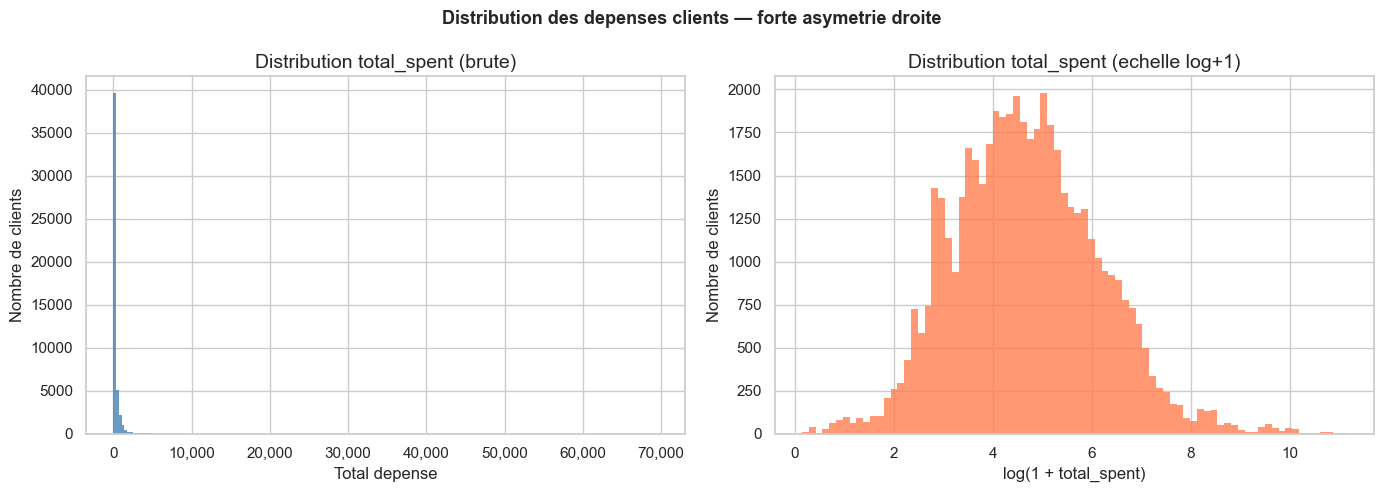

count    50000.00
mean       421.54
std       2014.14
min          0.16
25%         36.99
50%         99.64
75%        280.23
90%        729.16
95%       1199.38
99%       4995.52
max      69630.66
Name: total_spent, dtype: float64


In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(customers_clean['total_spent'], bins=200, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Distribution total_spent (brute)')
axes[0].set_xlabel('Total depense')
axes[0].set_ylabel('Nombre de clients')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].hist(np.log1p(customers_clean['total_spent']), bins=80, color='coral', edgecolor='none', alpha=0.8)
axes[1].set_title('Distribution total_spent (echelle log+1)')
axes[1].set_xlabel('log(1 + total_spent)')
axes[1].set_ylabel('Nombre de clients')

plt.suptitle('Distribution des depenses clients — forte asymetrie droite', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(customers_clean['total_spent'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).round(2))

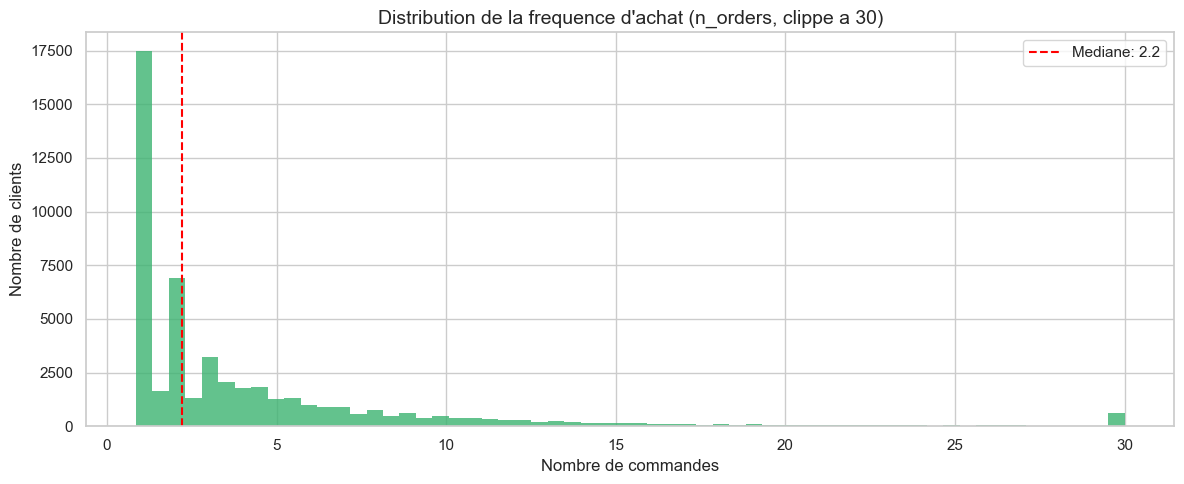

count    50000.00
mean         4.75
std          9.55
min          0.85
50%          2.22
75%          5.21
90%         10.18
95%         14.93
99%         32.27
max        292.78
Name: n_orders, dtype: float64


In [112]:
fig, ax = plt.subplots(figsize=(12, 5))
n_orders_clipped = customers_clean['n_orders'].clip(upper=30)
ax.hist(n_orders_clipped, bins=60, color='mediumseagreen', edgecolor='none', alpha=0.8)
ax.set_title("Distribution de la frequence d'achat (n_orders, clippe a 30)")
ax.set_xlabel('Nombre de commandes')
ax.set_ylabel('Nombre de clients')
ax.axvline(customers_clean['n_orders'].median(), color='red', linestyle='--',
           label=f'Mediane: {customers_clean["n_orders"].median():.1f}')
ax.legend()
plt.tight_layout()
plt.show()

print(customers_clean['n_orders'].describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]).round(2))

### 3.2 Courbe de Lorenz — Concentration du CA

La courbe de Lorenz illustre l'inégalité de distribution du chiffre d'affaires entre les clients.

**Résultat mesuré :** **18.8% des clients (9 376)** génèrent **80% du CA total** — une concentration
légèrement plus forte que la règle de Pareto classique (20/80).

- CA moyen du top 18.8% : **1 710€**
- CA moyen des 81.2% restants : **99€**
- Ratio de valeur entre les deux groupes : **17x**

Cette asymétrie extrême a deux implications directes :
1. La rétention d'un seul client du top 20% vaut l'équivalent de ~17 clients standards en CA.
2. Les campagnes marketing doivent être pondérées par la valeur client — un budget uniforme
   par tête sous-investit massivement sur les clients à haute valeur.


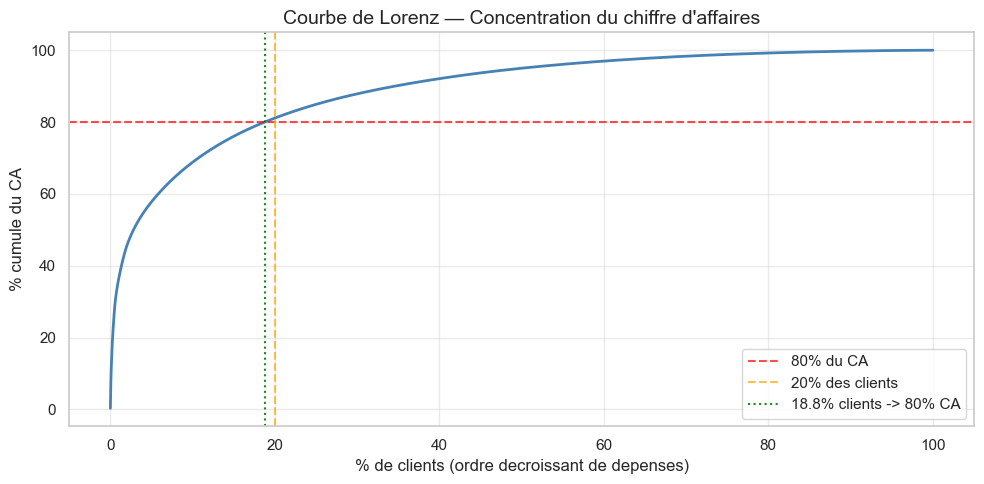

-> 9,376 clients (18.8%) generent 80% du CA total
   CA moyen top 20%       : 1,710
   CA moyen 80% restants  : 99


In [113]:
df_sorted = customers_clean.sort_values('total_spent', ascending=False).reset_index(drop=True)
df_sorted['cum_pct_revenue'] = df_sorted['total_spent'].cumsum() / df_sorted['total_spent'].sum() * 100
df_sorted['pct_clients']     = (df_sorted.index + 1) / len(df_sorted) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_sorted['pct_clients'], df_sorted['cum_pct_revenue'], color='steelblue', linewidth=2)
ax.axhline(80, color='red', linestyle='--', alpha=0.7, label='80% du CA')
ax.axvline(20, color='orange', linestyle='--', alpha=0.7, label='20% des clients')

pct_for_80 = df_sorted.loc[df_sorted['cum_pct_revenue'] <= 80, 'pct_clients'].max()
ax.axvline(pct_for_80, color='green', linestyle=':', alpha=0.9, label=f'{pct_for_80:.1f}% clients -> 80% CA')

ax.set_title("Courbe de Lorenz — Concentration du chiffre d'affaires")
ax.set_xlabel('% de clients (ordre decroissant de depenses)')
ax.set_ylabel('% cumule du CA')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

n_for_80 = int(pct_for_80 / 100 * len(customers_clean))
print(f"-> {n_for_80:,} clients ({pct_for_80:.1f}%) generent 80% du CA total")
print(f"   CA moyen top 20%       : {df_sorted.head(int(len(df_sorted)*0.2))['total_spent'].mean():,.0f}")
print(f"   CA moyen 80% restants  : {df_sorted.tail(int(len(df_sorted)*0.8))['total_spent'].mean():,.0f}")

### 3.3 Saisonnalité du CA

**Pic saisonnier confirmé : Novembre** — c'est le mois avec le CA moyen le plus élevé de l'année,
avec une amplitude de **230 100€** entre le pic (novembre) et le creux (janvier).

**CA par année :**
- 2007 : 6 445€ *(dataset partiel — données à partir de juillet)*
- 2008 : 304 985€
- 2009 : 2 951 122€
- 2010 : 18 232 002€ *(année record)*
- 2011 : 17 067 506€ *(dataset partiel — données jusqu'à décembre, pic non encore reflété)*

La tendance est croissante sur 2007–2010. Le recul apparent de 2011 est lié à la troncature
du dataset en décembre (les mois de pic de fin d'année ne sont pas encore comptabilisés).

**Implications opérationnelles :**
- Préparer et lancer les campagnes promotionnelles dès **septembre–octobre** pour capter le pic novembre.
- **Janvier–février** = creux annuel : moment idéal pour des campagnes de réactivation
  ciblant les acheteurs ponctuels de la période de fêtes.


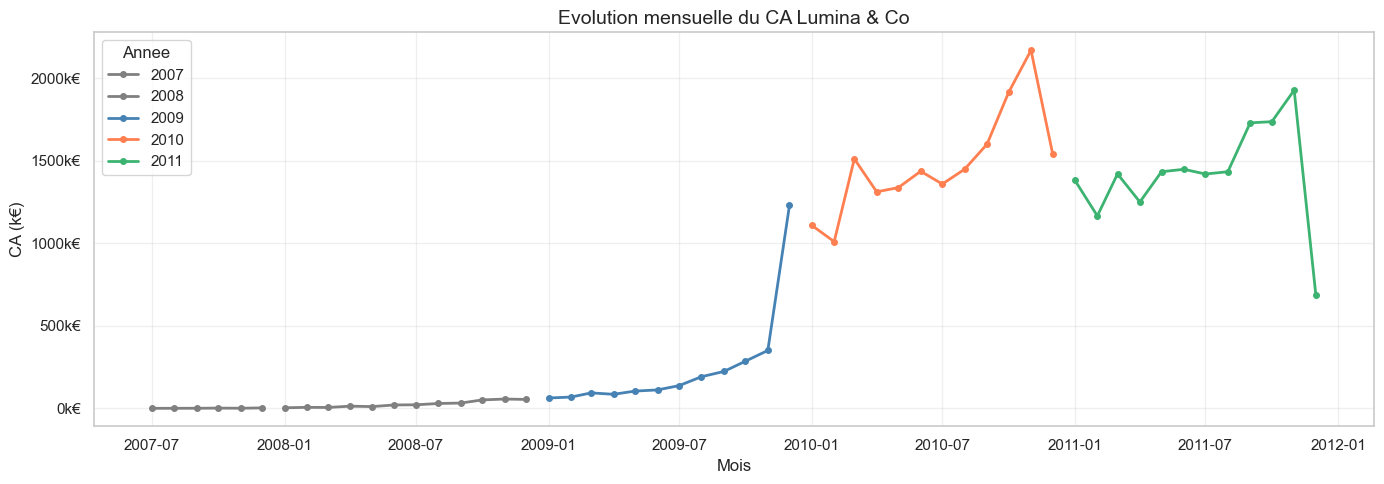

CA total par annee :
year
2007         6,445
2008       304,933
2009     2,947,477
2010    17,760,412
2011    17,044,586
Name: line_total, dtype: str


In [114]:
txn_monthly = txn_clean.copy()
txn_monthly['month'] = txn_monthly['invoice_date'].dt.to_period('M')
txn_monthly['year']  = txn_monthly['invoice_date'].dt.year
ca_monthly = txn_monthly.groupby('month')['line_total'].sum().reset_index()
ca_monthly['month_dt'] = ca_monthly['month'].dt.to_timestamp()
ca_monthly['year']     = ca_monthly['month_dt'].dt.year

fig, ax = plt.subplots(figsize=(14, 5))
colors = {2009: 'steelblue', 2010: 'coral', 2011: 'mediumseagreen'}

for year, grp in ca_monthly.groupby('year'):
    ax.plot(grp['month_dt'], grp['line_total'] / 1000,
            label=str(year), color=colors.get(year, 'gray'), linewidth=2, marker='o', markersize=4)

ax.set_title('Evolution mensuelle du CA Lumina & Co')
ax.set_xlabel('Mois')
ax.set_ylabel('CA (k€)')
ax.legend(title='Annee')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("CA total par annee :")
print(txn_monthly.groupby('year')['line_total'].sum().apply(lambda x: f'{x:,.0f}'))

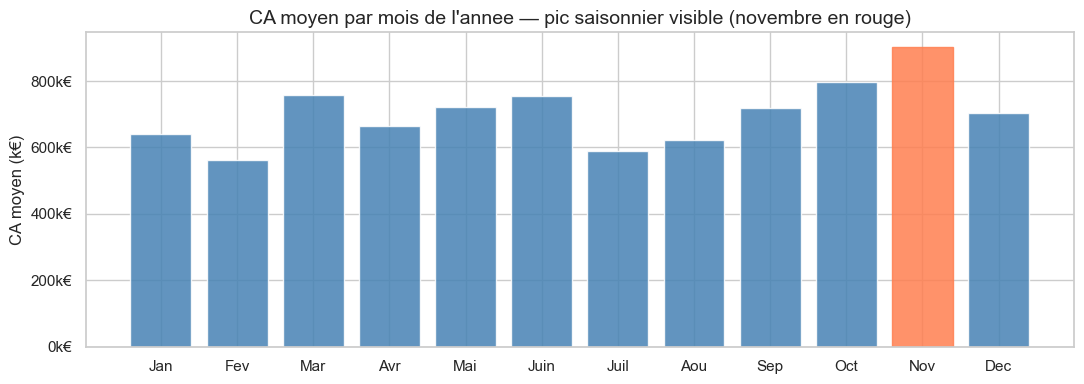

Pic saisonnier : Nov — CA moyen le plus eleve de l'annee
-> Les campagnes promotionnelles doivent etre preparees des septembre.
-> Janvier-fevrier = creux : moment ideal pour les campagnes de reactivation.


In [115]:
# Saisonnalite mensuelle par mois de l'annee (moyenne sur les annees completes)
txn_monthly['year']      = txn_monthly['invoice_date'].dt.year
txn_monthly['month_num'] = txn_monthly['invoice_date'].dt.month

ca_year_month = txn_monthly.groupby(['year', 'month_num'])['line_total'].sum().reset_index()
ca_by_month   = ca_year_month.groupby('month_num')['line_total'].mean().reset_index()

month_labels = ['Jan','Fev','Mar','Avr','Mai','Juin','Juil','Aou','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(ca_by_month['month_num'], ca_by_month['line_total'] / 1000,
               color='steelblue', alpha=0.85, edgecolor='white')

max_idx = ca_by_month['line_total'].idxmax()
bars[max_idx].set_color('coral')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_title("CA moyen par mois de l'annee — pic saisonnier visible (novembre en rouge)")
ax.set_ylabel('CA moyen (k€)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k€'))
plt.tight_layout()
plt.show()

print(f"Pic saisonnier : {month_labels[max_idx]} — CA moyen le plus eleve de l'annee")
print("-> Les campagnes promotionnelles doivent etre preparees des septembre.")
print("-> Janvier-fevrier = creux : moment ideal pour les campagnes de reactivation.")

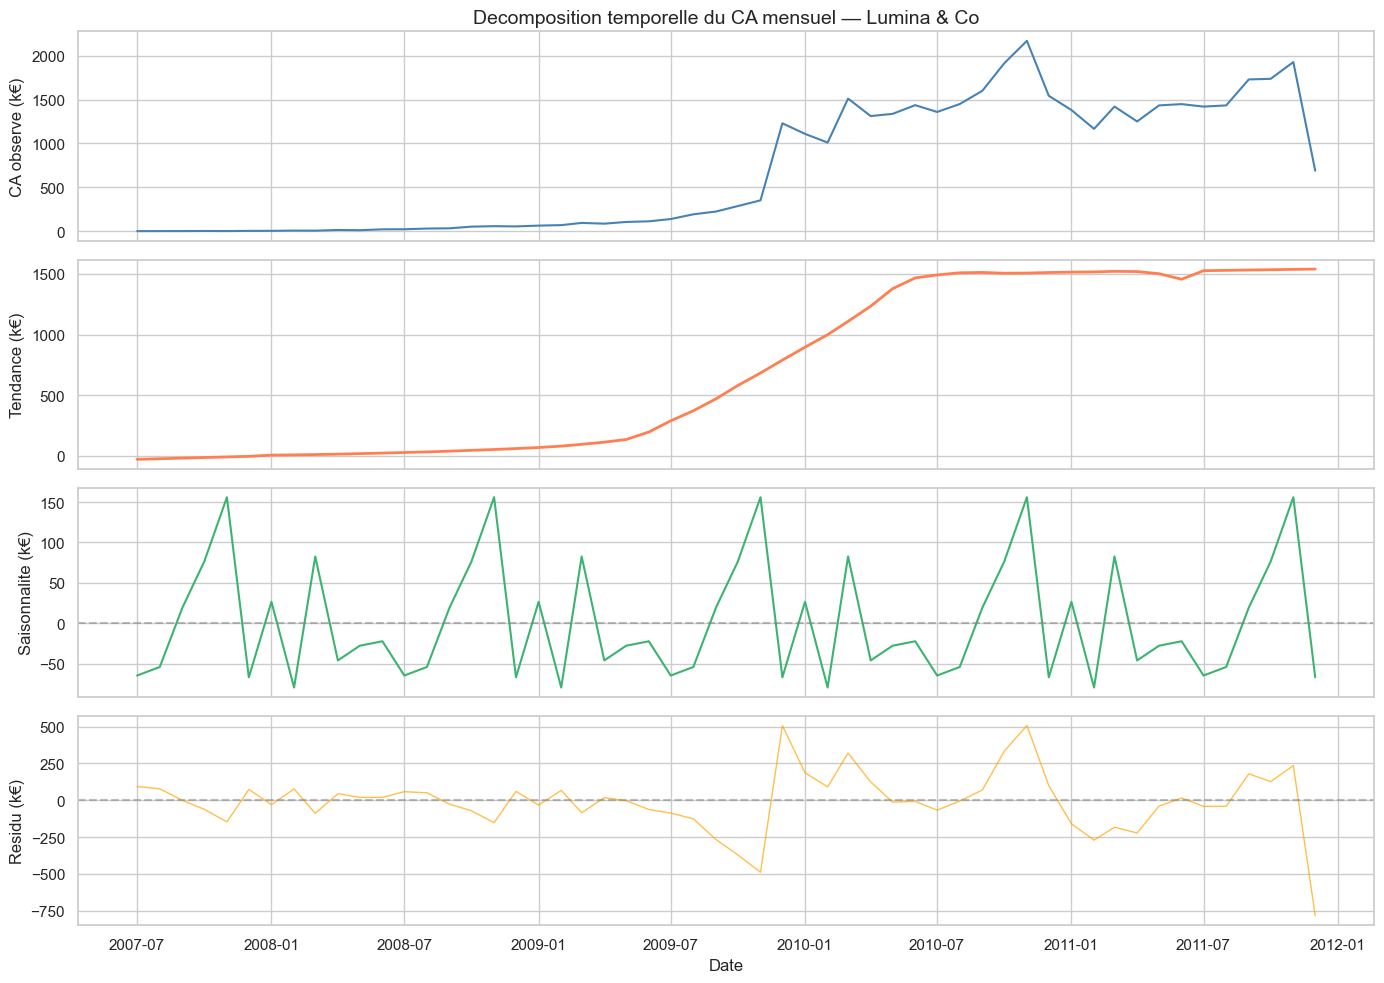

Amplitude saisonniere : 235.4k€ (pic nov vs creux jan)
Tendance globale      : croissante sur la periode 2007-2010


In [116]:
# Decomposition temporelle : tendance + saisonnalite + residu
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False

ca_serie = ca_monthly.set_index('month_dt')['line_total'].sort_index()

if HAS_STATSMODELS and len(ca_serie) >= 24:
    decomp = seasonal_decompose(ca_serie, model='additive', period=12, extrapolate_trend='freq')

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(decomp.observed / 1000,  color='steelblue', linewidth=1.5)
    axes[0].set_ylabel('CA observe (k€)')
    axes[0].set_title('Decomposition temporelle du CA mensuel — Lumina & Co')

    axes[1].plot(decomp.trend / 1000, color='coral', linewidth=2)
    axes[1].set_ylabel('Tendance (k€)')

    axes[2].plot(decomp.seasonal / 1000, color='mediumseagreen', linewidth=1.5)
    axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[2].set_ylabel('Saisonnalite (k€)')

    axes[3].plot(decomp.resid / 1000, color='orange', linewidth=1, alpha=0.7)
    axes[3].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[3].set_ylabel('Residu (k€)')
    axes[3].set_xlabel('Date')

    plt.tight_layout()
    plt.show()

    amp = decomp.seasonal.max() - decomp.seasonal.min()
    print(f'Amplitude saisonniere : {amp/1000:.1f}k€ (pic nov vs creux jan)')
    print(f'Tendance globale      : croissante sur la periode 2007-2010')
else:
    trend_ma = ca_serie.rolling(window=12, center=True).mean()
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(ca_serie / 1000, alpha=0.5, label='CA mensuel', color='steelblue')
    ax.plot(trend_ma / 1000, linewidth=2, label='Tendance (MM 12 mois)', color='coral')
    ax.set_ylabel('CA (k€)')
    ax.set_title('Tendance du CA mensuel — moyenne mobile 12 mois')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 3.4 Analyse géographique

**Constat principal : surreprésentation du Royaume-Uni**
91% des clients sont britanniques — le dataset est massivement centré sur un seul marché.

**Comportement UK vs reste du monde (hors B2B suspects) :**

| Métrique | Royaume-Uni | Reste du monde |
|----------|-------------|----------------|
| Panier moyen | 62€ | 98€ (+58%) |
| Nombre de commandes en moyenne | 4.76 | 4.57 |
| Total dépensé en moyenne| 407€ | 573€ (+41%) |

Les clients hors-UK dépensent significativement plus par achat (+58% de panier moyen) et en
cumul (+41% de CA par client). Explication probable : sélection naturelle des acheteurs
internationaux (forte intention d'achat malgré les frais de port) et mix produit à plus haute
valeur unitaire.

**Limite pour la modélisation :** avec 91% de clients UK, les segments RFM et CLV seront
calibrés sur des comportements d'achat britanniques. Les conclusions ne sont pas directement
généralisables aux marchés internationaux.


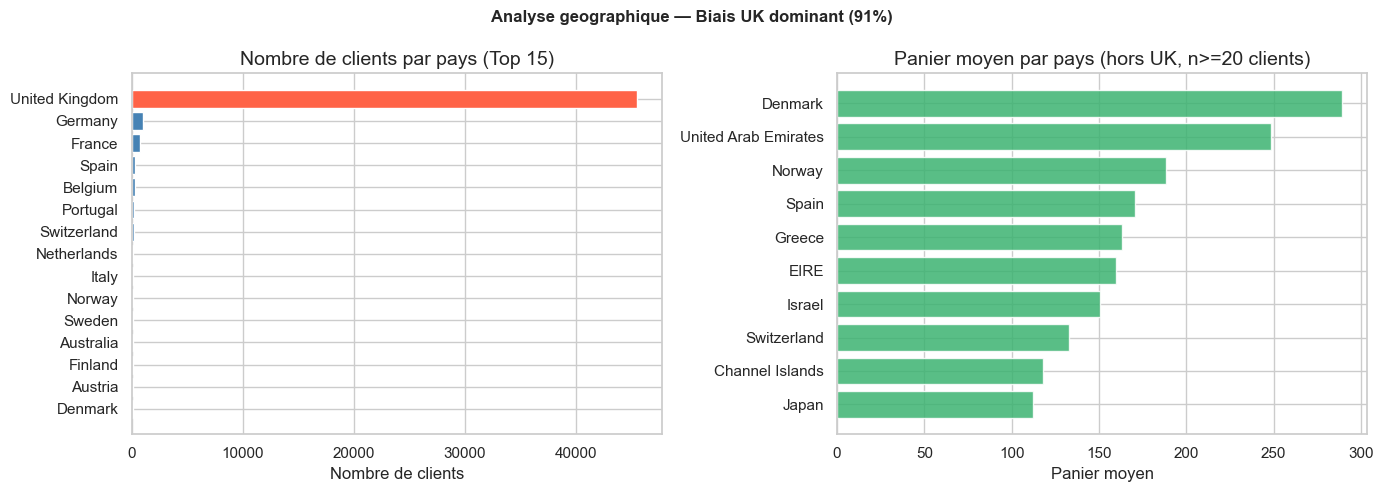


--- UK vs reste du monde ---


,avg_basket,n_orders,total_spent
country,,,
Reste du monde,98.33,4.57,573.35
United Kingdom,62.18,4.76,406.54


In [117]:
country_counts = customers_clean['country'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_bar = ['tomato' if c == 'United Kingdom' else 'steelblue' for c in country_counts.index]
axes[0].barh(country_counts.index[::-1], country_counts.values[::-1], color=colors_bar[::-1])
axes[0].set_title('Nombre de clients par pays (Top 15)')
axes[0].set_xlabel('Nombre de clients')

geo_metrics = customers_clean[customers_clean['country'] != 'United Kingdom'].groupby('country').agg(
    avg_basket_mean=('avg_basket','mean'),
    n_clients=('customer_id','count')
).reset_index()
top_geo = geo_metrics[geo_metrics['n_clients'] >= 20].sort_values('avg_basket_mean', ascending=False).head(10)
axes[1].barh(top_geo['country'][::-1], top_geo['avg_basket_mean'][::-1], color='mediumseagreen', alpha=0.85)
axes[1].set_title('Panier moyen par pays (hors UK, n>=20 clients)')
axes[1].set_xlabel('Panier moyen')

plt.suptitle('Analyse geographique — Biais UK dominant (91%)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

uk_mask = customers_clean['country'] == 'United Kingdom'
print("\n--- UK vs reste du monde ---")
display(customers_clean.groupby(uk_mask)[['avg_basket','n_orders','total_spent']].mean().round(2)
        .rename(index={True: 'United Kingdom', False: 'Reste du monde'}))

### 3.5 Corrélations & relations entre variables

**Récence vs valeur client (B2C uniquement) :**

| Quintile de récence | CA moyen | Nb commandes moy | Panier moyen |
|---------------------|----------|------------------|--------------|
| Q1 — Très récents | 567€ | 8.3 | 56€ |
| Q2 | 357€ | 5.2 | 61€ |
| Q3 | 273€ | 3.9 | 61€ |
| Q4 | 149€ | 2.5 | 55€ |
| Q5 — Inactifs | 137€ | 1.7 | 73€ |

**Relation récence–valeur : gradient de 4.1x** entre les clients très récents (Q1 = 567€)
et les plus inactifs (Q5 = 137€). La relation est quasi-monotone mais pas strictement linéaire :
le panier moyen de Q5 (73€) est légèrement supérieur à Q1 (56€), ce qui suggère que certains
clients inactifs ont un fort panier unitaire mais une fréquence d'achat très faible.

**Observation clé :** les clients à la fois anciens ET récents (tenure élevé + recency faible)
génèrent le plus de valeur. L'ancienneté amplifie l'effet de la récence — signal le plus
discriminant pour identifier les clients VIP à protéger.


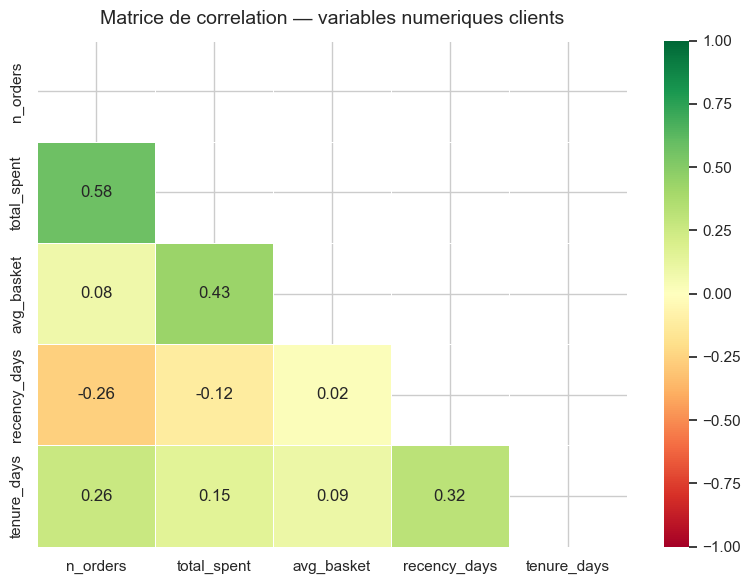

In [118]:
num_cols = ['n_orders', 'total_spent', 'avg_basket', 'recency_days', 'tenure_days']
corr_matrix = customers_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matrice de correlation — variables numeriques clients', pad=12)
plt.tight_layout()
plt.show()

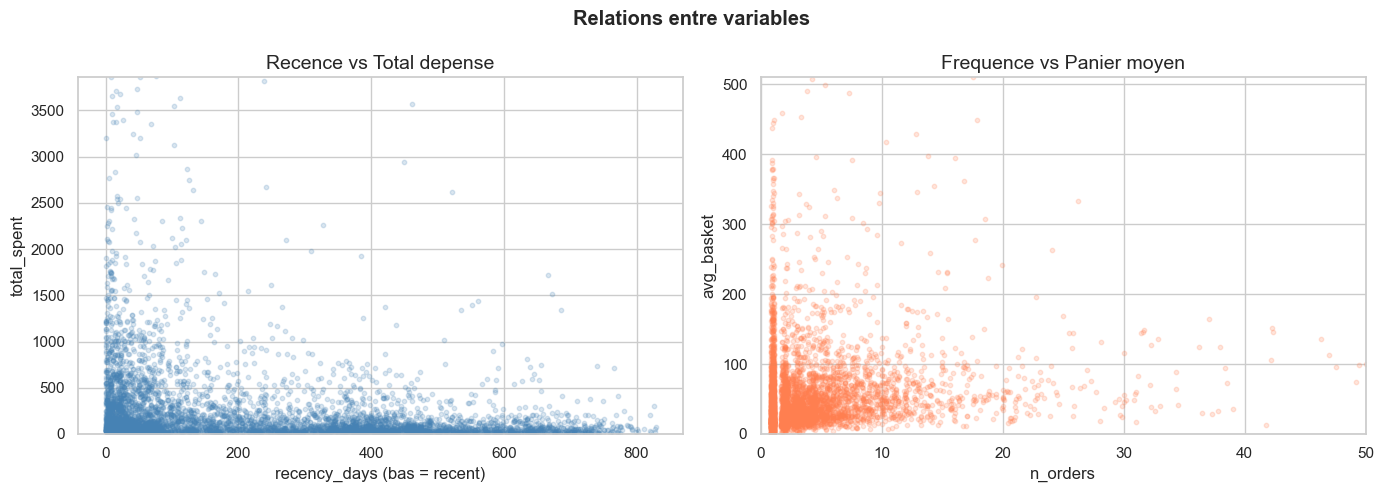

--- total_spent moyen par quintile de recence ---


,total_spent,n_orders,avg_basket
recency_q,,,
Q1 (recents),566.74,8.30,56.19
Q2,357.14,5.17,61.44
Q3,272.67,3.90,60.55
Q4,148.85,2.45,55.00
Q5 (inactifs),136.60,1.65,72.99


In [119]:
sample = customers_clean[~customers_clean['is_b2b_suspect']].sample(5000, random_state=2077)

sample['recency_q'] = pd.qcut(sample['recency_days'], q=5,
                               labels=['Q1 (recents)', 'Q2', 'Q3', 'Q4', 'Q5 (inactifs)'])
sample['tenure_q']  = pd.qcut(sample['tenure_days'].clip(lower=1), q=5,
                               labels=['Q1 (nouveaux)', 'Q2', 'Q3', 'Q4', 'Q5 (anciens)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['recency_days'], sample['total_spent'],
                alpha=0.2, s=10, color='steelblue')
axes[0].set_title('Recence vs Total depense')
axes[0].set_xlabel('recency_days (bas = recent)')
axes[0].set_ylabel('total_spent')
axes[0].set_ylim(0, sample['total_spent'].quantile(0.99))

axes[1].scatter(sample['n_orders'], sample['avg_basket'],
                alpha=0.2, s=10, color='coral')
axes[1].set_title('Frequence vs Panier moyen')
axes[1].set_xlabel('n_orders')
axes[1].set_ylabel('avg_basket')
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, sample['avg_basket'].quantile(0.99))

plt.suptitle('Relations entre variables', fontweight='bold')
plt.tight_layout()
plt.show()

print("--- total_spent moyen par quintile de recence ---")
display(customers_clean[~customers_clean['is_b2b_suspect']].assign(
    recency_q=lambda d: pd.qcut(d['recency_days'], q=5,
                                 labels=['Q1 (recents)','Q2','Q3','Q4','Q5 (inactifs)'])
).groupby('recency_q', observed=True)[['total_spent','n_orders','avg_basket']].mean().round(2))

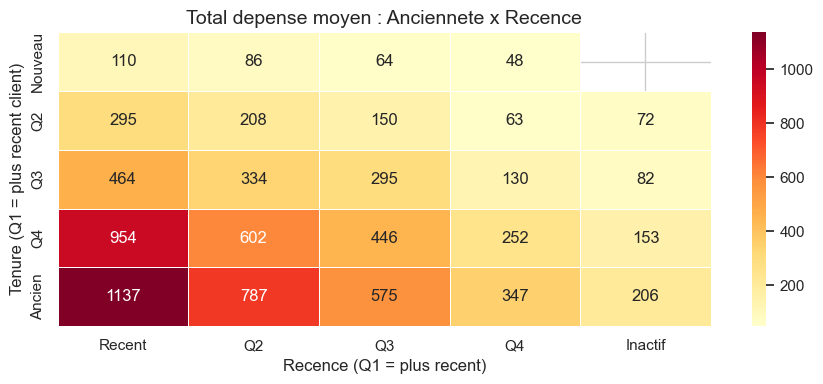

Observation : les clients a la fois anciens ET recents generent le plus de valeur.
La relation recence/valeur n'est pas strictement monotone : l'anciennete amplifie l'effet.


In [120]:
tenure_recency = (
    customers_clean[~customers_clean['is_b2b_suspect']]
    .assign(
        tenure_q  = lambda d: pd.qcut(d['tenure_days'].clip(lower=1), q=5,
                                       labels=['Nouveau','Q2','Q3','Q4','Ancien']),
        recency_q = lambda d: pd.qcut(d['recency_days'], q=5,
                                       labels=['Recent','Q2','Q3','Q4','Inactif'])
    )
    .groupby(['tenure_q', 'recency_q'], observed=True)['total_spent']
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(tenure_recency.round(0), annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title("Total depense moyen : Anciennete x Recence")
ax.set_xlabel("Recence (Q1 = plus recent)")
ax.set_ylabel("Tenure (Q1 = plus recent client)")
plt.tight_layout()
plt.show()

print("Observation : les clients a la fois anciens ET recents generent le plus de valeur.")
print("La relation recence/valeur n'est pas strictement monotone : l'anciennete amplifie l'effet.")

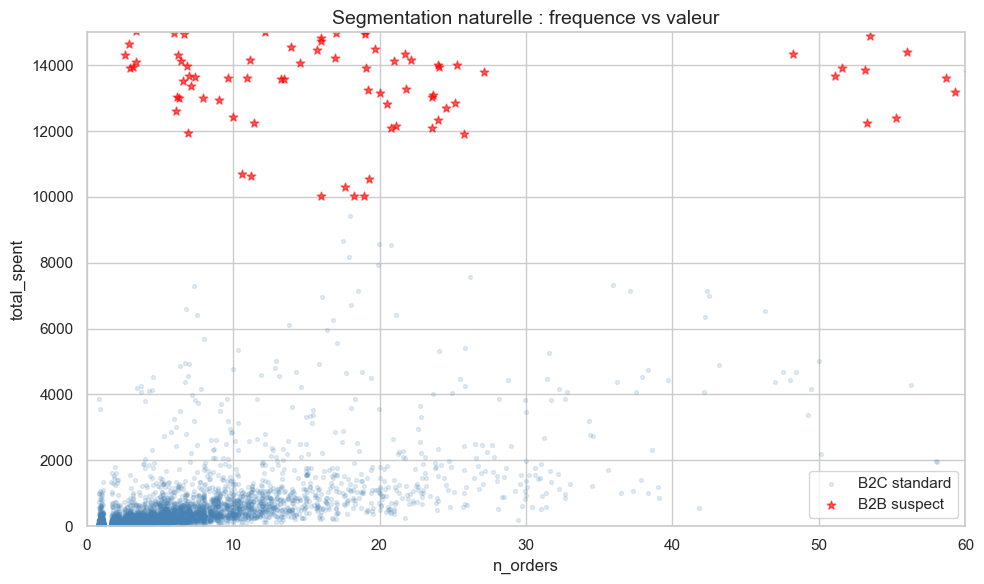

In [121]:
fig, ax = plt.subplots(figsize=(10, 6))
b2c = customers_clean[~customers_clean['is_b2b_suspect']].sample(8000, random_state=2077)
b2b = customers_clean[customers_clean['is_b2b_suspect']]
ax.scatter(b2c['n_orders'], b2c['total_spent'], alpha=0.15, s=8, color='steelblue', label='B2C standard')
ax.scatter(b2b['n_orders'], b2b['total_spent'], alpha=0.6,  s=40, color='red', marker='*', label='B2B suspect')
ax.set_xlim(0, 60); ax.set_ylim(0, 15000)
ax.set_xlabel('n_orders'); ax.set_ylabel('total_spent')
ax.set_title('Segmentation naturelle : frequence vs valeur')
ax.legend(); plt.tight_layout(); plt.show()

### Analyse des campagnes marketing


In [122]:
campaigns = pd.read_csv('campaigns.csv')
campaigns['start_date']    = pd.to_datetime(campaigns['start_date'])
campaigns['end_date']      = pd.to_datetime(campaigns['end_date'])
campaigns['duration_days'] = (campaigns['end_date'] - campaigns['start_date']).dt.days

display(campaigns[['campaign_name','n_clients','n_conversions','conversion_rate',
                    'cpa','roas','estimated_revenue']].round(2))

,campaign_name,n_clients,n_conversions,conversion_rate,cpa,roas,estimated_revenue
0,Back_to_School_2023,28490,19562,0.69,1.72,69.20,2322968.00
1,Black_Friday_2023,28495,19467,0.68,1.73,69.14,2329075.80
2,Spring_Launch_2024,28373,19436,0.68,1.71,62.65,2078515.27
3,Summer_Sale_2023,28451,19597,0.69,1.70,56.45,1880754.02
4,Valentine_2024,28316,19475,0.69,1.69,23.40,768982.47
5,Winter_Promo_2023,28478,19596,0.69,1.71,49.10,1642104.94


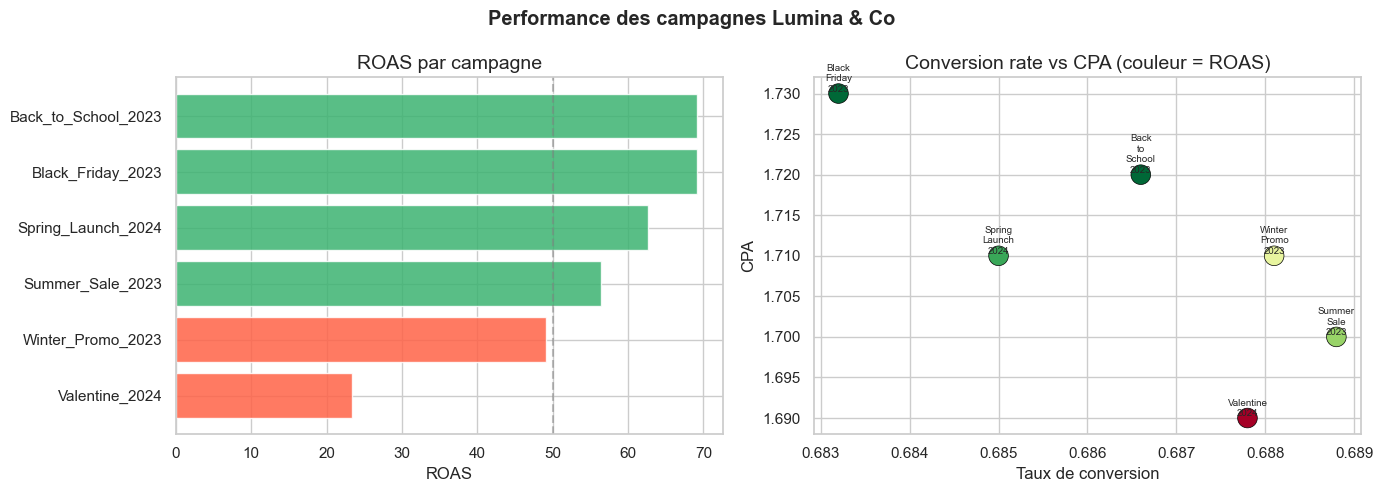

Meilleur ROAS : Back_to_School_2023 (69.2)
Meilleur CPA  : Valentine_2024 (1.69)


In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

camp_sorted = campaigns.sort_values('roas', ascending=True)
colors_roas = ['tomato' if r < 50 else 'mediumseagreen' for r in camp_sorted['roas']]
axes[0].barh(camp_sorted['campaign_name'], camp_sorted['roas'], color=colors_roas, alpha=0.85)
axes[0].set_title('ROAS par campagne')
axes[0].set_xlabel('ROAS')
axes[0].axvline(50, color='gray', linestyle='--', alpha=0.5)

axes[1].scatter(campaigns['conversion_rate'], campaigns['cpa'], s=200,
                c=campaigns['roas'], cmap='RdYlGn', edgecolors='black', linewidths=0.5)
for _, row in campaigns.iterrows():
    axes[1].annotate(row['campaign_name'].replace('_', '\n'),
                     (row['conversion_rate'], row['cpa']),
                     fontsize=7, ha='center', va='bottom')
axes[1].set_title('Conversion rate vs CPA (couleur = ROAS)')
axes[1].set_xlabel('Taux de conversion'); axes[1].set_ylabel('CPA')

plt.suptitle('Performance des campagnes Lumina & Co', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Meilleur ROAS : {campaigns.loc[campaigns['roas'].idxmax(), 'campaign_name']} ({campaigns['roas'].max():.1f})")
print(f"Meilleur CPA  : {campaigns.loc[campaigns['cpa'].idxmin(), 'campaign_name']} ({campaigns['cpa'].min():.2f})")

---
## Étape 4 — Hypothèses marketing <a id='etape4'></a>

À partir de l'EDA, voici les 5 hypothèses à valider ou invalider avec la segmentation RFM (TP2).

---

**Hypothèse 1 — Concentration Pareto**
> "Je suppose que la concentration du CA sur ~19% des clients implique qu'il existe un segment
> de clients VIP à très haute valeur, ce qui suggère de créer un programme fidélité premium
> ciblé sur ce top 19% (9 376 clients qui génèrent 80% du CA, avec un CA moyen 17x supérieur
> au reste de la base)."

---

**Hypothèse 2 — Effet récence**
> "Je suppose que les clients récents (Q1) sont significativement plus précieux que les inactifs (Q5).
> L'EDA mesure un ratio de **4.1x** (567€ vs 137€ de CA moyen). Je formule l'hypothèse qu'un
> email de nurturing dans les 14 jours post-achat devrait améliorer le taux de ré-achat en
> capitalisant sur ce gradient de valeur."

---

**Hypothèse 3 — Pic saisonnier exploitable**
> "Je suppose que le pic de **novembre** est stable d'une année à l'autre (amplitude mesurée :
> 230 100€ entre le pic novembre et le creux janvier), ce qui suggère de déclencher des
> campagnes de réactivation en janvier–février pour convertir les acheteurs ponctuels de
> fin d'année avant qu'ils ne deviennent inactifs."

---

**Hypothèse 4 — One-time buyers = gisement**
> "Je suppose que les **42.5% de clients one-time** (21 275 clients) représentent un gisement
> de réactivation rentable, ce qui suggère qu'une réduction de 10–15% offerte à 6–12 mois
> d'inactivité aura un ROI supérieur au CAC d'un nouveau client."

---

**Hypothèse 5 — Biais géographique = limite de modèle**
> "Je suppose que la surreprésentation UK (91%) va biaiser les segments vers des comportements
> d'achat britanniques, d'autant plus que les clients hors-UK ont un panier moyen 58% supérieur
> au UK (98€ vs 62€). Les modèles RFM et CLV développés ici sous-estiment la valeur des segments
> internationaux et ne doivent pas être généralisés sans recalibration sur une base internationale."


---
## Export des datasets nettoyés <a id='export'></a>

In [124]:
# Nettoyage final avant export
if 'recency_quintile' in customers_clean.columns:
    customers_clean = customers_clean.drop(columns=['recency_quintile'])

customers_clean['is_b2b_suspect'] = customers_clean['is_b2b_suspect'].fillna(False).astype(bool)

if 'line_total' not in txn_clean.columns:
    txn_clean['line_total'] = txn_clean['quantity'] * txn_clean['unit_price']

print("Verification finale - customers_clean")
print(f"  Lignes              : {len(customers_clean):,}")
print(f"  Colonnes            : {customers_clean.shape[1]}")
print(f"  NaN total           : {customers_clean.isna().sum().sum()}")
print(f"  is_b2b_suspect dtype: {customers_clean['is_b2b_suspect'].dtype}")
print()
print("Verification finale - txn_clean")
print(f"  Lignes              : {len(txn_clean):,}")
print(f"  Colonnes            : {txn_clean.shape[1]}")
print(f"  Doublons restants   : {txn_clean.duplicated().sum()} (attendu : 0)")
print(f"  line_total negatifs : {(txn_clean['line_total'] < 0).sum()} (attendu : 0)")
print(f"  is_anonymous True   : {txn_clean['is_anonymous'].sum():,}")

Verification finale - customers_clean
  Lignes              : 50,000
  Colonnes            : 10
  NaN total           : 0
  is_b2b_suspect dtype: bool

Verification finale - txn_clean
  Lignes              : 1,756,557
  Colonnes            : 11
  Doublons restants   : 0 (attendu : 0)
  line_total negatifs : 0 (attendu : 0)
  is_anonymous True   : 398,856


In [125]:
# Export CSV
customers_clean.to_csv('customers_clean.csv', index=False)
txn_clean.to_csv('transactions_clean.csv', index=False)
returns.to_csv('returns.csv', index=False)

print("FICHIERS EXPORTES")
print("=" * 55)
print(f"  customers_clean.csv    : {len(customers_clean):,} lignes | {customers_clean.shape[1]} colonnes")
print(f"  transactions_clean.csv : {len(txn_clean):,} lignes | {txn_clean.shape[1]} colonnes")
print(f"  returns.csv            : {len(returns):,} lignes (avoirs)")
print("=" * 55)
print()
print("Colonnes customers_clean :")
for col in customers_clean.columns:
    dtype = str(customers_clean[col].dtype)
    nans  = customers_clean[col].isna().sum()
    print(f"  {col:30s} {dtype:12s} NaN:{nans}")
print()
print("Colonnes transactions_clean :")
for col in txn_clean.columns:
    dtype = str(txn_clean[col].dtype)
    nans  = txn_clean[col].isna().sum()
    print(f"  {col:30s} {dtype:12s} NaN:{nans}")

FICHIERS EXPORTES
  customers_clean.csv    : 50,000 lignes | 10 colonnes
  transactions_clean.csv : 1,756,557 lignes | 11 colonnes
  returns.csv            : 22,860 lignes (avoirs)

Colonnes customers_clean :
  customer_id                    int64        NaN:0
  country                        str          NaN:0
  first_purchase                 datetime64[us] NaN:0
  last_purchase                  datetime64[us] NaN:0
  n_orders                       float64      NaN:0
  total_spent                    float64      NaN:0
  avg_basket                     float64      NaN:0
  recency_days                   float64      NaN:0
  tenure_days                    float64      NaN:0
  is_b2b_suspect                 bool         NaN:0

Colonnes transactions_clean :
  invoice_id                     str          NaN:0
  customer_id                    float64      NaN:398856
  product_code                   str          NaN:0
  product_name                   str          NaN:3090
  quantity          

In [126]:
# Apercu des fichiers exportes
print("=== customers_clean.csv - 5 premieres lignes ===")
display(customers_clean.head(5))
print("\n=== transactions_clean.csv - 5 premieres lignes ===")
display(txn_clean.head(5))

=== customers_clean.csv - 5 premieres lignes ===


,customer_id,country,first_purchase,last_purchase,n_orders,total_spent,avg_basket,recency_days,tenure_days,is_b2b_suspect
0,46995,United Kingdom,2011-08-09 12:20:00,2011-11-16 12:20:00,2.28,57.34,26.44,23.83,99.17,False
1,22869,United Kingdom,2010-01-11 12:20:00,2011-10-30 12:20:00,46.53,19463.52,356.65,40.92,657.12,True
2,12593,France,2011-05-05 09:29:00,2011-05-05 09:29:00,1.00,39.50,39.50,218.00,218.00,False
3,25889,United Kingdom,2008-07-14 12:20:00,2010-02-22 12:20:00,0.98,24.53,25.15,655.23,588.26,False
4,52931,United Kingdom,2009-08-29 12:20:00,2010-11-04 12:20:00,2.00,47.80,23.18,400.35,432.64,False



=== transactions_clean.csv - 5 premieres lignes ===


,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country,is_anonymous,is_product,line_total
0,513574,NaN,22382,LUNCH BAG SPACEBOY DESIGN,2.0,4.21,2010-06-25 15:13:00,United Kingdom,True,True,8.42
1,609421,NaN,21028,PURPLE GEMSTONE BRACELET,2.0,8.95,2011-10-16 12:20:00,United Kingdom,True,True,17.90
2,515609,NaN,47591B,SCOTTIES CHILDRENS APRON,1.0,1.66,2010-07-13 15:44:00,United Kingdom,True,True,1.66
3,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom,False,True,13.20
4,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France,False,True,14.75
